Vamos a utilizar un dataset para obtener más información sobre las características de los pacientes incluidos en cada uno de los grupos y comprobar si las diferencias en la expresión de ciertos genes va de la mano de diferencias también en otras variables. Vamos a trabaar con 6 variables distintas.

In [5]:
#Importamos los datos y comprobamos que se ha leido correctamente
import pandas as pd

url_datos = 'https://drive.google.com/uc?id=1VF3MqQ3J7GBc527ClL2IgJ23XTc5-hX7'
conjunto_datos = pd.read_csv(url_datos, delimiter=',', na_values='-')

print('Variables leidas:')
print(', '.join(conjunto_datos.columns))

Variables leidas:
MUTATIONSUBTYPES, UV-signature, RNASEQ-CLUSTER_CONSENHIER, MethTypes.201408, MIRCluster, LYMPHOCYTE.SCORE


In [6]:
#Este conjunto de datos contiene un número fijo de varibales y cada
# instancia tiene un determinado valor para cada una de esas variables.

print("Primeras 5 instancias del conjunto de datos:")
print(conjunto_datos.head())

Primeras 5 instancias del conjunto de datos:
       MUTATIONSUBTYPES  UV-signature RNASEQ-CLUSTER_CONSENHIER  \
0  BRAF_Hotspot_Mutants  UV signature                   keratin   
1   RAS_Hotspot_Mutants  UV signature                   keratin   
2  BRAF_Hotspot_Mutants  UV signature                   keratin   
3   RAS_Hotspot_Mutants  UV signature                   keratin   
4             Triple_WT        not UV                    immune   

        MethTypes.201408  MIRCluster  LYMPHOCYTE.SCORE  
0            normal-like  MIR.type.3               2.0  
1  CpG island-methylated  MIR.type.2               4.0  
2            normal-like  MIR.type.1               5.0  
3        hypo-methylated  MIR.type.2               2.0  
4  CpG island-methylated  MIR.type.2               6.0  


In [9]:
#Vamos a comprobar el valor que puede tomar cada una de estas variables
print("Distintos valores existentes para cada variable:")
for col in conjunto_datos.columns:
    print('*%s-> %s' % (col, ', '.join(conjunto_datos.loc[conjunto_datos[col].notnull(), 
                                                          col].sort_values().unique().astype(str))))

Distintos valores existentes para cada variable:
*MUTATIONSUBTYPES-> BRAF_Hotspot_Mutants, NF1_Any_Mutants, RAS_Hotspot_Mutants, Triple_WT
*UV-signature-> UV signature, not UV
*RNASEQ-CLUSTER_CONSENHIER-> MITF-low, immune, keratin
*MethTypes.201408-> CpG island-methylated, hyper-methylated, hypo-methylated, normal-like
*MIRCluster-> MIR.type.1, MIR.type.2, MIR.type.3, MIR.type.4
*LYMPHOCYTE.SCORE-> 0.0, 2.0, 3.0, 4.0, 5.0, 6.0


Para trabajar en términos de ítems y transacciones necesitamos realizar un cambio de formato. Para ello, un ítem será un par (variable, valor) y cada istancia será una transacción que contiene una lista de pares (variable, valor).
Para ello tendremos una tabla en la que existe una columna por cada ítem posible y cada fila toma el valor 1 para aquellos ítems que sí estén contenidos en la transacción y 0 para los que no.

In [11]:
transacciones = pd.get_dummies(conjunto_datos, columns=conjunto_datos.columns, prefix_sep='-')
transacciones.head()

#Esto representa en formato variable=valor, de forma que los itemsets y 
# reglas que generemos posteriormente sean más legibles.

,MUTATIONSUBTYPES-BRAF_Hotspot_Mutants,MUTATIONSUBTYPES-NF1_Any_Mutants,MUTATIONSUBTYPES-RAS_Hotspot_Mutants,MUTATIONSUBTYPES-Triple_WT,UV-signature-UV signature,UV-signature-not UV,RNASEQ-CLUSTER_CONSENHIER-MITF-low,RNASEQ-CLUSTER_CONSENHIER-immune,RNASEQ-CLUSTER_CONSENHIER-keratin,MethTypes.201408-CpG island-methylated,...,MIRCluster-MIR.type.1,MIRCluster-MIR.type.2,MIRCluster-MIR.type.3,MIRCluster-MIR.type.4,LYMPHOCYTE.SCORE-0.0,LYMPHOCYTE.SCORE-2.0,LYMPHOCYTE.SCORE-3.0,LYMPHOCYTE.SCORE-4.0,LYMPHOCYTE.SCORE-5.0,LYMPHOCYTE.SCORE-6.0
0,True,False,False,False,True,False,False,False,True,False,...,False,False,True,False,False,True,False,False,False,False
1,False,False,True,False,True,False,False,False,True,True,...,False,True,False,False,False,False,False,True,False,False
2,True,False,False,False,True,False,False,False,True,False,...,True,False,False,False,False,False,False,False,True,False
3,False,False,True,False,True,False,False,False,True,False,...,False,True,False,False,False,True,False,False,False,False
4,False,False,False,True,False,True,False,True,False,True,...,False,True,False,False,False,False,False,False,False,True


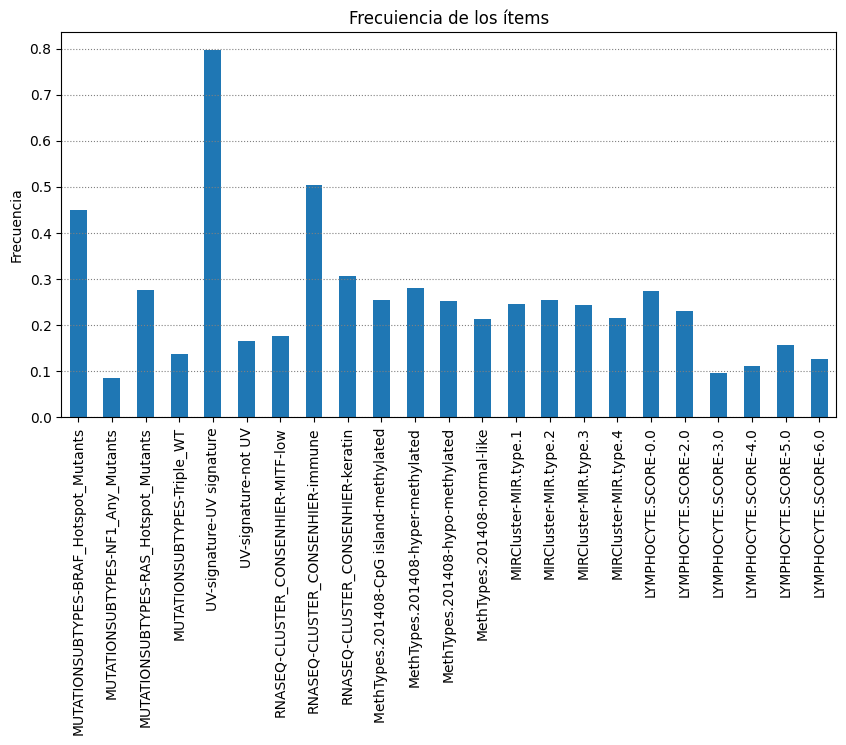

In [12]:
#Obtención de itemsets frecuentes
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10,5))
item_freqs = transacciones.sum()/len(transacciones)
item_freqs.plot(kind='bar', title='Frecuiencia de los ítems')
plt.ylabel('Frecuencia')
plt.grid(axis='y', ls=':', color='grey')
plt.show()

Observamos en la figura un número significativo de ítmes con una frecuencia inferior a 0,2. Esto implica que si fijamos un umbral del 20% dejamos fuera todos estos ítems y sus posibles reglas de asoiación. Es importante tener en cuenta esto a la hora de fijar un umbral de soporte.

Vamos a probar con el algoritmo FP-Growth para identificar los ítemsets frecuentes en un conjunto de datots dado un soporte mínimo.

In [16]:
from mlxtend.frequent_patterns import fpgrowth

itemset_frecuentes = fpgrowth(transacciones.astype('bool'), min_support=0.015,
                              use_colnames=True, max_len=4)
print('%d itemsets frecuentes identificados.' % (len(itemset_frecuentes)))

#Mostramos las 5 primeras filas
print(itemset_frecuentes.head())

965 itemsets frecuentes identificados.
    support                                           itemsets
0  0.795796             frozenset({UV-signature-UV signature})
1  0.450450  frozenset({MUTATIONSUBTYPES-BRAF_Hotspot_Mutan...
2  0.306306     frozenset({RNASEQ-CLUSTER_CONSENHIER-keratin})
3  0.243243                 frozenset({MIRCluster-MIR.type.3})
4  0.231231                  frozenset({LYMPHOCYTE.SCORE-2.0})


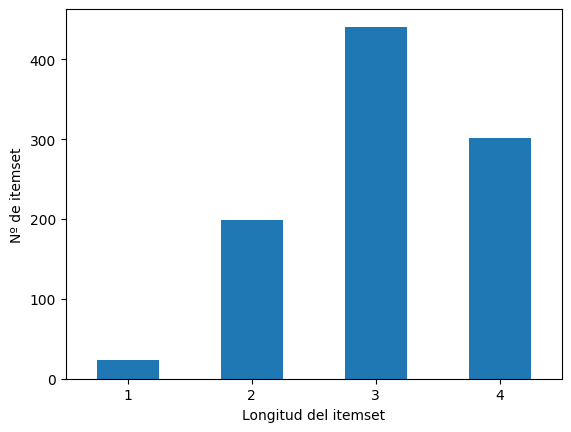

In [17]:
#Cada ítemset presenta una longitud diferente, por ello vamos a comprobar la lóngitud de los itemset
longitud_itemsets = itemset_frecuentes['itemsets'].apply(len).value_counts().sort_index()

#Gráfico de barras para representarlo
fig = plt.figure()
ax = fig.add_subplot(111)
longitud_itemsets.plot(kind='bar', ax=ax, rot=0)
ax.set_xlabel("Longitud del itemset")
ax.set_ylabel("Nº de itemset")
plt.show()

Una vez conocidos los itemsets frecuentes y vista su longitud, podemos generar las reglas de asociación con una confianza mínima. Al igual que ocurre con el umbral de soporte, el valor que elijamos depende del problema.

In [18]:
from mlxtend.frequent_patterns import association_rules

reglas_asociacion = association_rules(itemset_frecuentes, metric='confidence', min_threshold=0.85)
print('%d reglas generadas.' % (len(reglas_asociacion)))

317 reglas generadas.


Partimos de un umbral de confianza superior a 0.85, por lo que se ha podido generar alguna regla irrelevante. Para ello podemos considerar otras medidas, como lift o leverage, para complementar al umbral de confianza. 

In [ ]:
reglas_asociacion = reglas_asociacion.loc[(reglas_asociacion['lift']> 1) &
                                          (reglas_asociacion['leverage'] > 0)]
print('%d reglas filtradas.' % (len(reglas_asociacion)))

317 reglas filtradas.


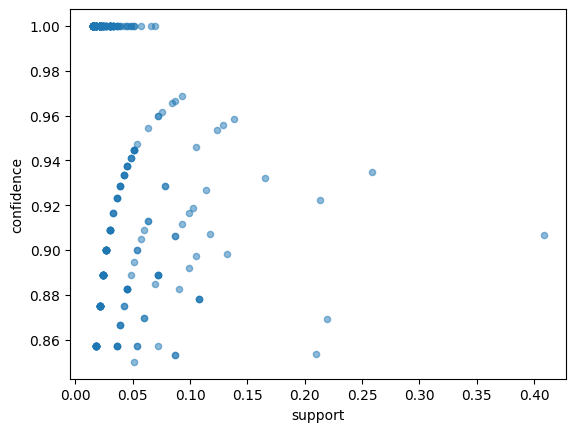

In [21]:
#Gráfico de dispersión de soporte de las reglas frente a su confianza
reglas_asociacion.plot.scatter('support', 'confidence', alpha=0.5)
plt.show()